# Exploratory Data Analysis (EDA)

The objective of this exploratory data analysis is to identify patterns, trends, and factors associated with traffic accidents.

The analysis focuses on accident severity, temporal patterns, weather conditions, visibility, and road infrastructure characteristics.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [17]:
df_clean = pd.read_csv('../data/processed/us_accidents_clean.csv')

In [18]:
df_clean.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,...,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Temperature_C,Distance_km,Visibility_km,Wind_Speed_kmh,Duration_Hours,Hour
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,...,Night,Night,Night,Night,2.72,0.02,16.09,NaN,5.233333,5
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,...,Night,Night,Night,Day,3.28,0.02,16.09,NaN,0.500000,6
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,...,Night,Night,Day,Day,2.22,0.02,16.09,5.63,0.500000,6
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,...,Night,Day,Day,Day,1.72,0.02,14.48,7.40,0.500000,7
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,...,Day,Day,Day,Day,2.22,0.02,9.66,5.63,0.500000,7


# Accident Severity Distribution

The severity distribution reveals that most accidents belong to severity levels 2 and 3.

Severity level 2 accounts for approximately 55% of all recorded accidents, while severity level 3 represents nearly 45%.

Severity levels 1 and 4 are extremely rare, indicating that the majority of accidents in this dataset are classified as moderately severe incidents.

   Severity  Count
0         1     98
1         2  55025
2         3  44844
3         4     33


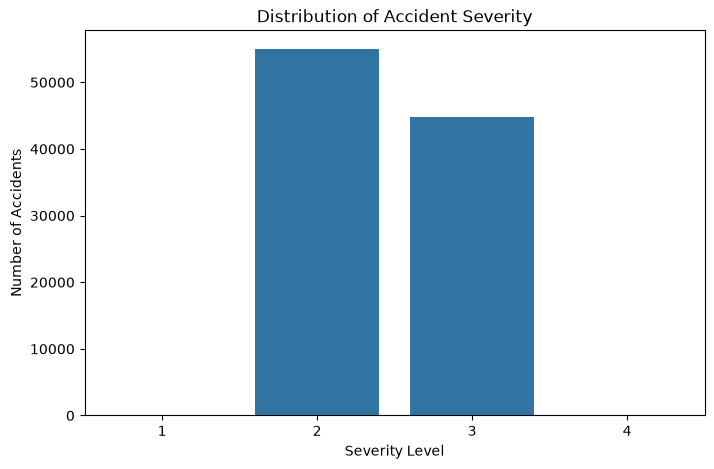

In [32]:
severity_counts = (
    df_clean['Severity']
    .value_counts()
    .sort_index()
    .reset_index()
)

severity_counts.columns = ['Severity', 'Count']

print(severity_counts)

plt.figure(figsize=(8,5))

sns.barplot(
    data=severity_counts,
    x='Severity',
    y='Count'
)

plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')

plt.show()

# Accidents by Hour

Accidents occur throughout the day, but their distribution is not uniform.

The average accident time is approximately 1:30 PM, while the median accident time is 2:00 PM.

This suggests that accident occurrence is concentrated during daytime hours when traffic density and road usage are generally higher.

    Hour  Count
0      0   2240
1      1   1895
2      2   1895
3      3   1507
4      4   1303
5      5   1516
6      6   1378
7      7   2196
8      8   3142
9      9   5291
10    10   7285
11    11   7910
12    12   6219
13    13   5137
14    14   5208
15    15   4707
16    16   5293
17    17   5035
18    18   6144
19    19   6722
20    20   7404
21    21   4970
22    22   3773
23    23   1830


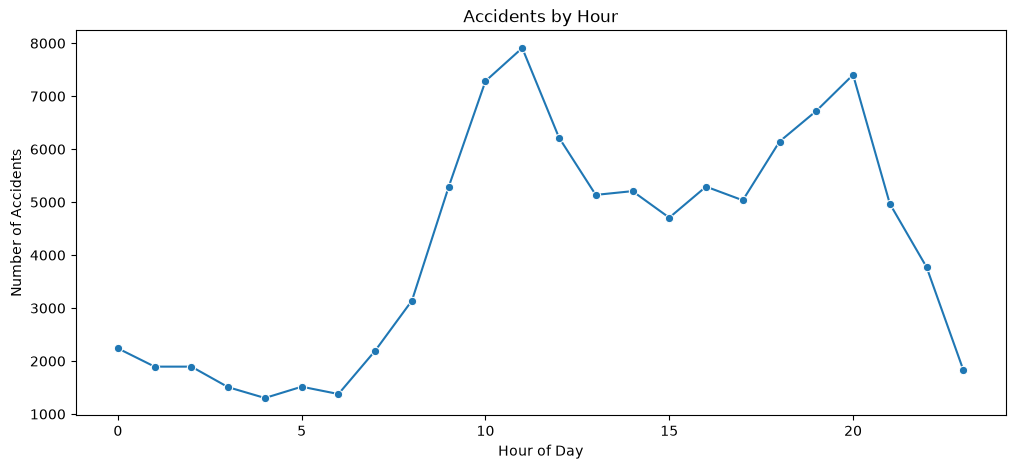

In [33]:
hour_counts = (
    df_clean['Hour']
    .value_counts()
    .sort_index()
    .reset_index()
)

hour_counts.columns = ['Hour', 'Count']

print(hour_counts)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hour_counts,
    x='Hour',
    y='Count',
    marker='o'
)

plt.title('Accidents by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')

plt.show()

# Day vs Night Analysis

The analysis shows that accidents occur more frequently during the day than at night.

Approximately 62.5% of accidents occurred during daylight conditions, while 37.5% occurred during nighttime conditions.

The higher number of daytime accidents is likely related to increased traffic volume and daily commuting activities.

  Period  Count
0    Day  62510
1  Night  37489


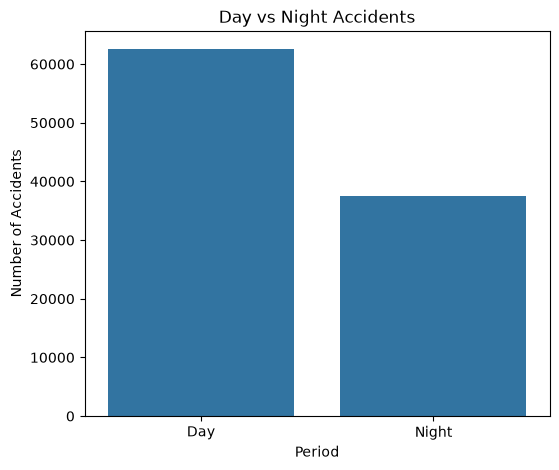

In [34]:
day_night = (
    df_clean['Sunrise_Sunset']
    .value_counts()
    .reset_index()
)

day_night.columns = ['Period', 'Count']

print(day_night)

plt.figure(figsize=(6,5))

sns.barplot(
    data=day_night,
    x='Period',
    y='Count'
)

plt.title('Day vs Night Accidents')
plt.xlabel('Period')
plt.ylabel('Number of Accidents')

plt.show()

# Weather Conditions Analysis

Weather conditions were examined to evaluate their relationship with accident occurrence.

Clear weather accounts for the majority of accidents, followed by Overcast, Mostly Cloudy, and Partly Cloudy conditions.

This result mainly reflects the fact that most driving activity takes place under normal weather conditions. Nevertheless, adverse weather conditions such as rain may increase accident risk by reducing visibility and road traction.

  Weather_Condition  Count
0             Clear  57255
1          Overcast  10255
2     Mostly Cloudy   8829
3     Partly Cloudy   8260
4  Scattered Clouds   5684
5        Light Rain   3211
6              Haze   2097
7              Fair   1039
8              Rain    829
9        Heavy Rain    202


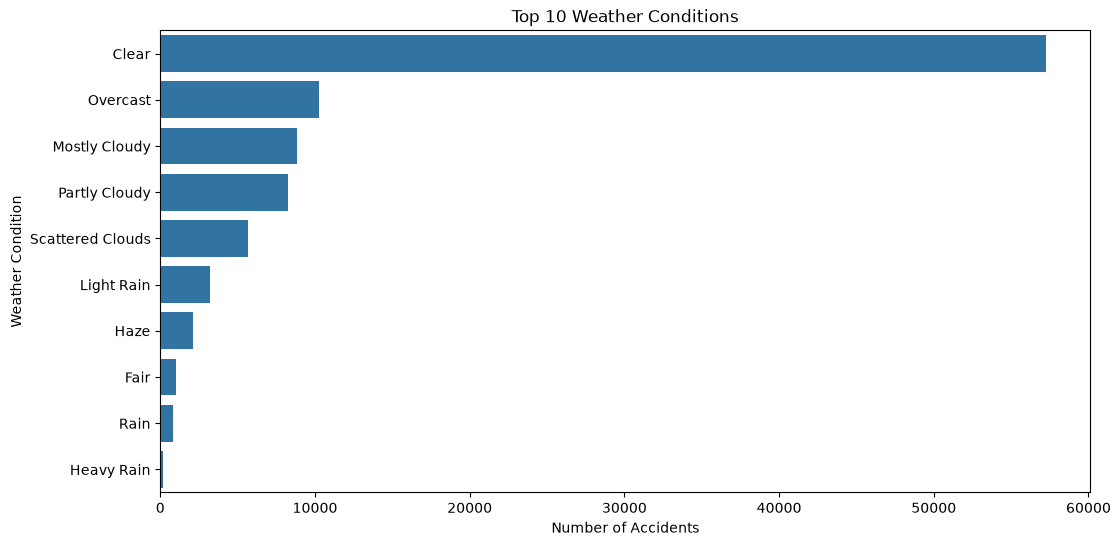

In [35]:
weather_counts = (
    df_clean['Weather_Condition']
    .value_counts()
    .head(10)
    .reset_index()
)

weather_counts.columns = ['Weather_Condition', 'Count']

print(weather_counts)

plt.figure(figsize=(12,6))

sns.barplot(
    data=weather_counts,
    x='Count',
    y='Weather_Condition'
)

plt.title('Top 10 Weather Conditions')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')

plt.show()

# Temperature Analysis

Temperature values were converted from Fahrenheit (°F) to Celsius (°C) to improve readability.

The temperature distribution provides insight into the environmental conditions under which accidents occur.

Understanding temperature patterns may help identify potential relationships between weather conditions and accident frequency.

count    98409.000000
mean        19.245153
std          7.057681
min        -16.000000
25%         14.390000
50%         18.890000
75%         23.890000
max         45.610000
Name: Temperature_C, dtype: float64


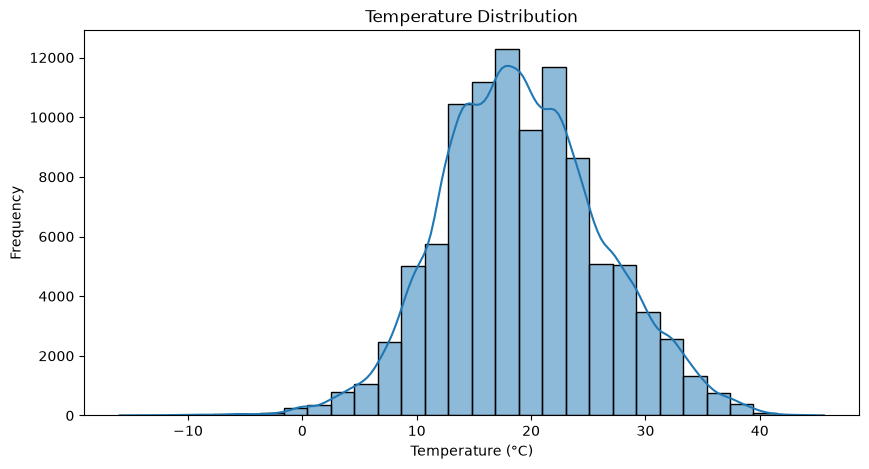

In [36]:
print(df_clean['Temperature_C'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df_clean['Temperature_C'].dropna(),
    bins=30,
    kde=True
)

plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.show()

# Visibility Analysis

Visibility is an important environmental factor that affects driver perception and reaction time.

Reduced visibility can make it more difficult for drivers to identify hazards and react appropriately.

Analyzing visibility levels helps assess the potential impact of environmental conditions on road safety.

count    98154.000000
mean        15.026270
std          3.033548
min          0.160000
25%         16.090000
50%         16.090000
75%         16.090000
max        128.750000
Name: Visibility_km, dtype: float64


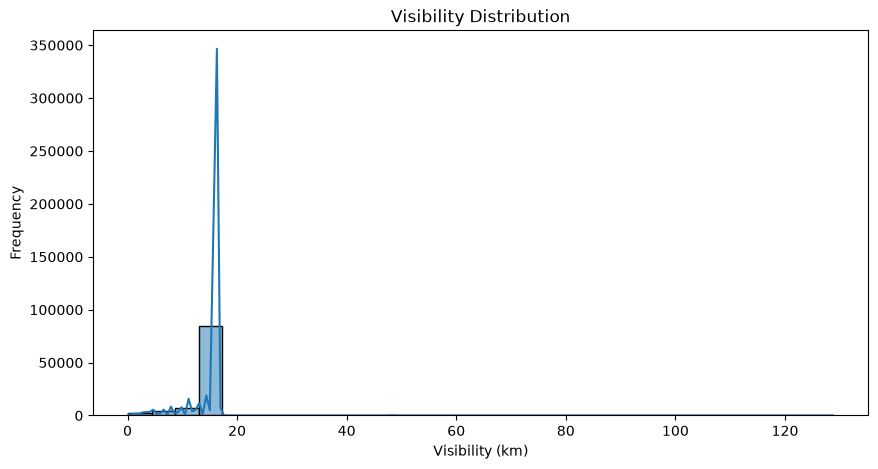

In [37]:
print(df_clean['Visibility_km'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df_clean['Visibility_km'].dropna(),
    bins=30,
    kde=True
)

plt.title('Visibility Distribution')
plt.xlabel('Visibility (km)')
plt.ylabel('Frequency')

plt.show()

# Junction Analysis

Road junctions were analyzed to investigate their relationship with accident occurrence.

Approximately 10.4% of accidents occurred at junctions, while nearly 89.6% occurred outside junction areas.

Although intersections are often considered high-risk locations, the majority of accidents in this sample occurred on regular road segments.

   Junction  Count
0     False  89566
1      True  10434


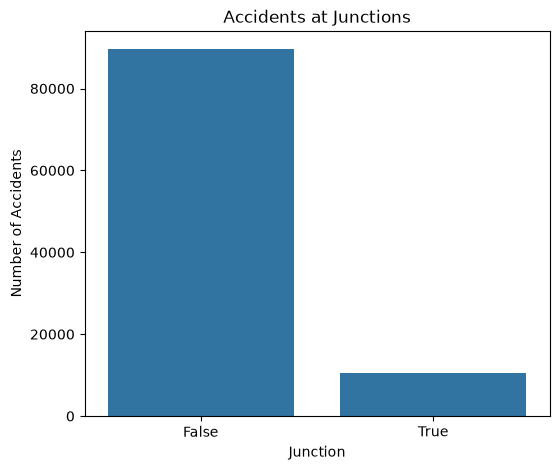

In [38]:
junction_counts = (
    df_clean['Junction']
    .value_counts()
    .reset_index()
)

junction_counts.columns = ['Junction', 'Count']

print(junction_counts)

plt.figure(figsize=(6,5))

sns.barplot(
    data=junction_counts,
    x='Junction',
    y='Count'
)

plt.title('Accidents at Junctions')
plt.xlabel('Junction')
plt.ylabel('Number of Accidents')

plt.show()

# Traffic Signal Analysis

The presence of traffic signals was examined as a potential factor influencing accident occurrence.

Approximately 10.7% of accidents occurred near traffic signals, while nearly 89.3% occurred in locations without traffic signals.

This suggests that most accidents occur away from signalized intersections, although traffic signals remain important elements of road infrastructure.

   Traffic_Signal  Count
0           False  89301
1            True  10699


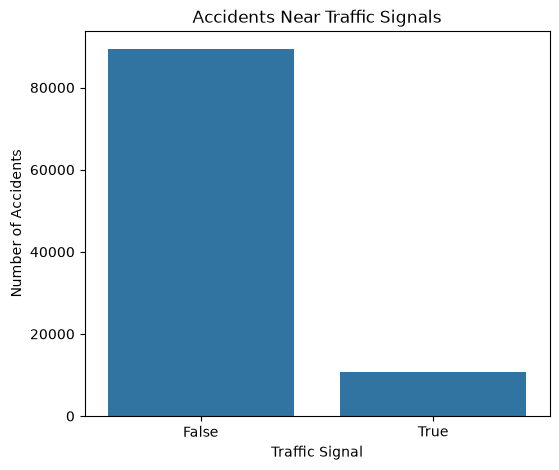

In [39]:
traffic_signal_counts = (
    df_clean['Traffic_Signal']
    .value_counts()
    .reset_index()
)

traffic_signal_counts.columns = ['Traffic_Signal', 'Count']

print(traffic_signal_counts)

plt.figure(figsize=(6,5))

sns.barplot(
    data=traffic_signal_counts,
    x='Traffic_Signal',
    y='Count'
)

plt.title('Accidents Near Traffic Signals')
plt.xlabel('Traffic Signal')
plt.ylabel('Number of Accidents')

plt.show()

# Geographical Distribution

The dataset sample is heavily dominated by California, which accounts for the vast majority of recorded accidents.

Only a limited number of observations originate from Ohio and West Virginia.

As a result, geographical findings primarily reflect accident patterns observed in California and should not be generalized to the entire United States.

            City  Count
0    Los Angeles   9792
1     Sacramento   5223
2      San Diego   3275
3       San Jose   3026
4        Oakland   1802
5     Long Beach   1343
6  San Francisco   1287
7      Riverside   1261
8         Corona   1095
9       Whittier   1019


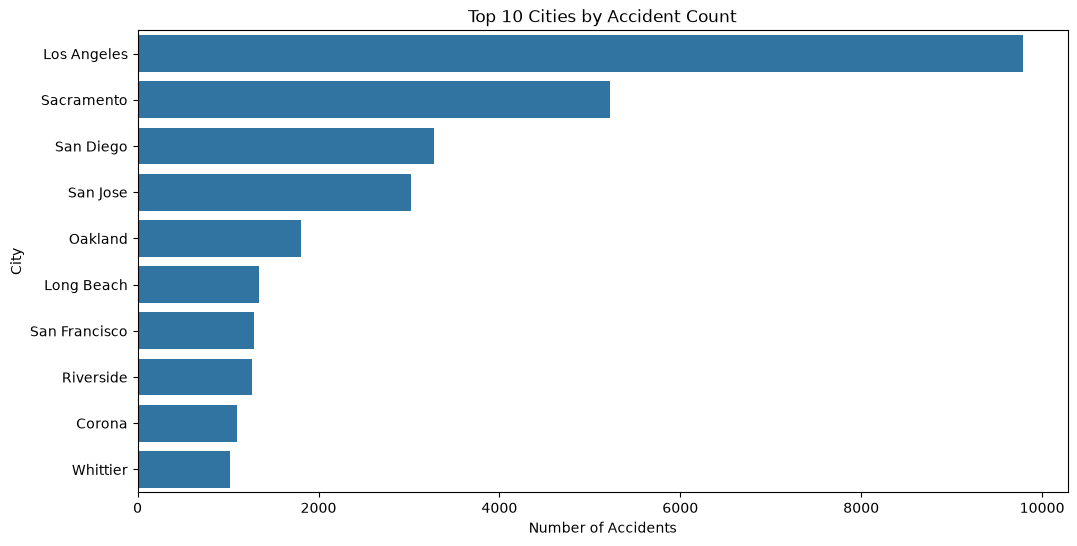

In [40]:
top_cities = (
    df_clean['City']
    .value_counts()
    .head(10)
    .reset_index()
)

top_cities.columns = ['City', 'Count']

print(top_cities)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cities,
    x='Count',
    y='City'
)

plt.title('Top 10 Cities by Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('City')

plt.show()

# Key Findings

The exploratory analysis revealed several important insights:

- Most accidents belong to severity levels 2 and 3.
- Accident occurrence is concentrated during daytime hours.
- Daytime accidents account for approximately 62.5% of all incidents.
- Clear weather conditions are associated with the largest number of recorded accidents.
- Most accidents occur outside junctions and away from traffic signals.
- The dataset sample is strongly dominated by California records.

These findings provide valuable insights into traffic accident patterns and establish a foundation for future predictive modeling and road safety studies.